In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/moni35/superstore-sales-csv/train.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/kaggle/input/datasets/moni35/superstore-sales-csv/train.csv', encoding='latin1')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (9800, 18)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Data cleaning
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month'] = df['Order Date'].dt.to_period('M')

# Monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

print("Monthly Sales:")
print(monthly_sales.head(10))

Monthly Sales:
     Month       Sales
0  2015-01  14205.7070
1  2015-02   4519.8920
2  2015-03  55205.7970
3  2015-04  27906.8550
4  2015-05  23644.3030
5  2015-06  34322.9356
6  2015-07  33781.5430
7  2015-08  27117.5365
8  2015-09  81623.5268
9  2015-10  31453.3930


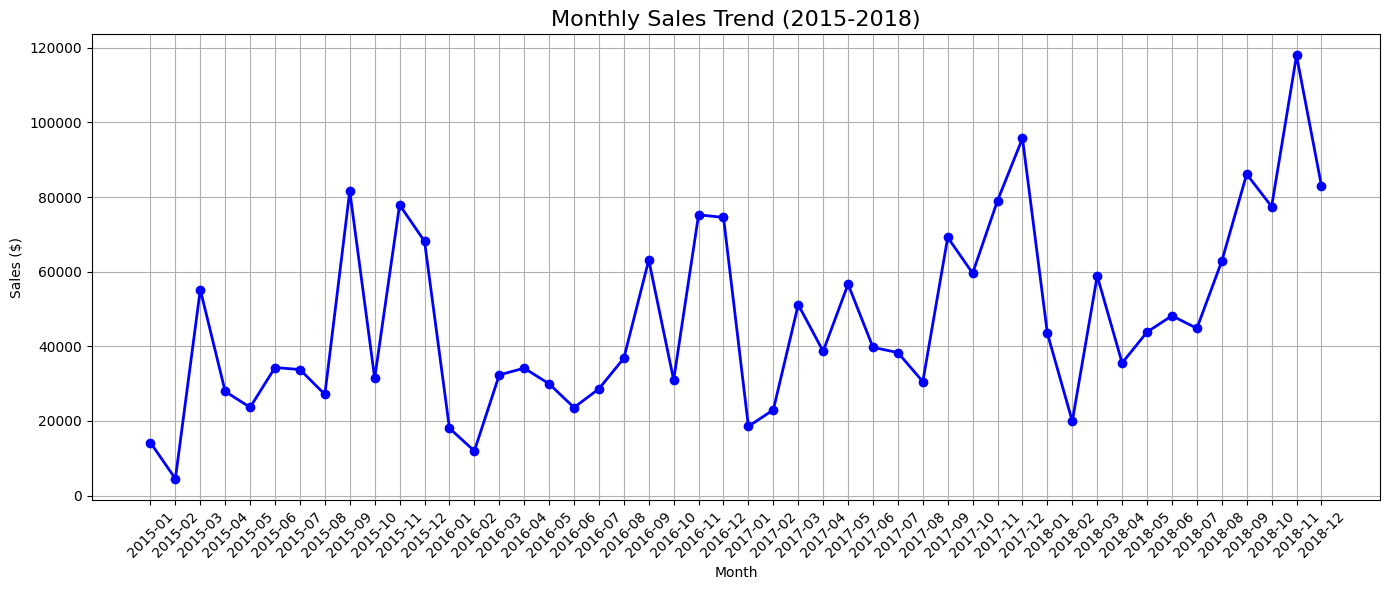

Graph ready!


In [4]:
# Sales Forecast Graph
plt.figure(figsize=(14,6))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], 
         marker='o', color='blue', linewidth=2)
plt.title('Monthly Sales Trend (2015-2018)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
print("Graph ready!")

In [5]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data for model
monthly_sales['Index'] = range(len(monthly_sales))

X = monthly_sales[['Index']]
y = monthly_sales['Sales']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 6 months
future_index = np.array([[len(monthly_sales)+i] for i in range(6)])
predictions = model.predict(future_index)

print("Next 6 months Sales Forecast:")
for i, pred in enumerate(predictions):
    print(f"Month {i+1}: ${pred:,.2f}")

Next 6 months Sales Forecast:
Month 1: $68,879.00
Month 2: $69,767.31
Month 3: $70,655.62
Month 4: $71,543.93
Month 5: $72,432.25
Month 6: $73,320.56


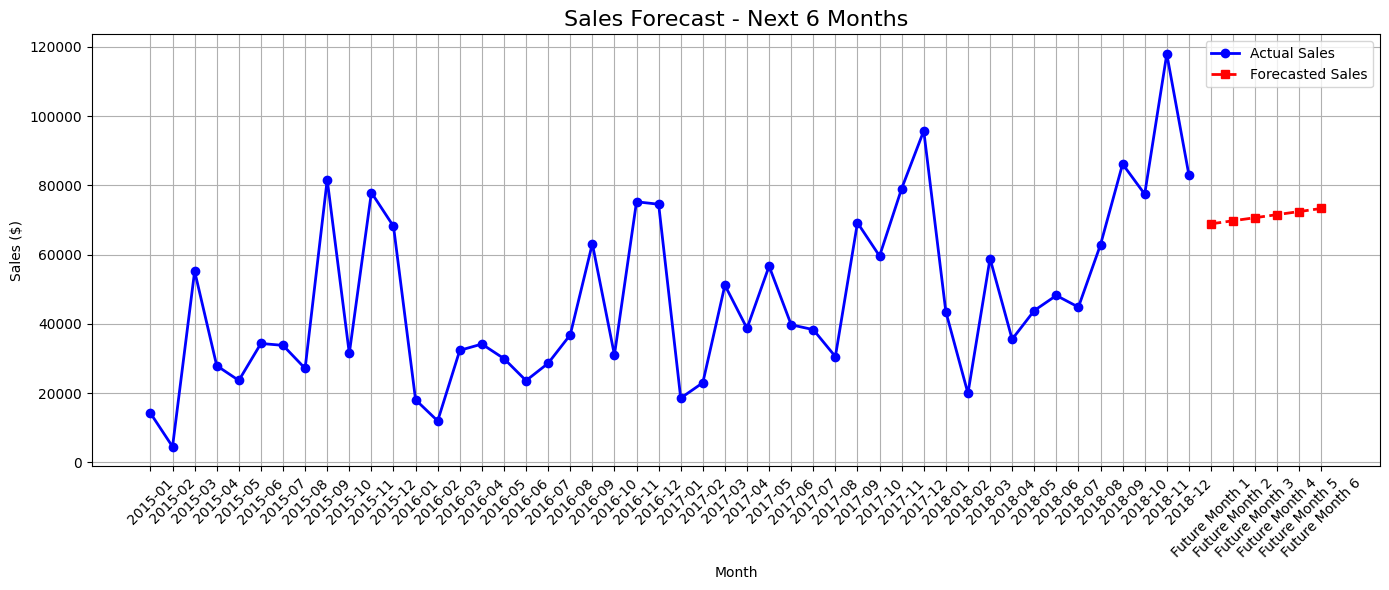

✅ Task 1 Complete!


In [6]:
# Final Forecast Graph
plt.figure(figsize=(14,6))

# Actual sales
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], 
         marker='o', color='blue', linewidth=2, label='Actual Sales')

# Forecast
future_months = [f'Future Month {i+1}' for i in range(6)]
plt.plot(future_months, predictions, 
         marker='s', color='red', linewidth=2, 
         linestyle='--', label='Forecasted Sales')

plt.title('Sales Forecast - Next 6 Months', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("✅ Task 1 Complete!")